# LeetCode #561: Array Partition I

https://leetcode.com/problems/array-partition/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n!)$ | $O(n)$ |
| **Optimal: Sort and Sum Even Indices** | $O(n \log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Generate every possible pairing of the 2n integers into n pairs, compute min of each pair, and take the maximum total. With $n!$ permutations, this is completely impractical beyond tiny inputs.

### Optimal: Sort and Sum Even Indices ★
Sort the array. In the sorted order, consecutive pairs (0,1), (2,3), … are optimal because sorting guarantees the gap between each pair is minimised — the wasted element is as small as possible. Sum elements at indices 0, 2, 4, … to get the answer.

**Constraints:**
* `1 <= n <= 10^4`
* `nums.length == 2 * n`
* `-10^4 <= nums[i] <= 10^4`

## Solutions

### C#

In [ ]:
public class Solution {
    public int ArrayPairSum(int[] nums) {
        // Sort so consecutive pairs are as close together as possible
        Array.Sort(nums);
        int sum = 0;
        // Each pair's minimum is at the even index after sorting
        for (int i = 0; i < nums.Length; i += 2) {
            sum += nums[i];
        }
        return sum;
    }
}

### Python

In [ ]:
class Solution:
    def arrayPairSum(self, nums: list[int]) -> int:
        # Sort so consecutive pairs are as close together as possible
        nums.sort()
        # Each pair's minimum is at the even index after sorting
        return sum(nums[::2])

### Go

In [ ]:
import "sort"
func arrayPairSum(nums []int) int {
    // Sort so consecutive pairs are as close together as possible
    sort.Ints(nums)
    sum := 0
    // Each pair's minimum is at the even index after sorting
    for i := 0; i < len(nums); i += 2 {
        sum += nums[i]
    }
    return sum
}

### Rust

In [ ]:
impl Solution {
    pub fn array_pair_sum(mut nums: Vec<i32>) -> i32 {
        // Sort so consecutive pairs are as close together as possible
        nums.sort();
        // Each pair's minimum is at the even index after sorting
        nums.iter().step_by(2).sum()
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [1,4,3,2]`  
Sorted: `[1,2,3,4]`. Pairs are (1,2) and (3,4); their minimums are 1 and 3. $1 + 3 = 4$. Return **4**.

### 2. Slightly Complex
**Input:** `nums = [6,2,6,5,1,2]`  
Sorted: `[1,2,2,5,6,6]`. Even-index elements are 1, 2, 6; sum = $1 + 2 + 6 = 9$. Return **9**.

### 3. Edge Case: Time Factor
**Input:** `nums = [-10000,10000,-9999,9999,\u2026,0,1]` ($2n = 20000$ elements, alternating extremes).  
Sort visits all $O(n \log n)$ comparisons — no early exit possible. Every element must be placed correctly before the sum can be computed.

### 4. Edge Case: Space Factor
**Input:** Already-sorted array `[1,1,2,2,\u2026,10000,10000]`.  
Sort is $O(1)$ extra (in-place); the sum accumulator is the only extra variable. True $O(1)$ space case.

### 5. Almost-Impossible but Plausible
**Input:** `nums = [-10000,-10000]` ($n = 1$, both at the INT min bound).  
Sorted: `[-10000,-10000]`; even-index sum = $-10000$. Negative output is valid; no overflow since $-10^4 \times 10^4 = -10^8$ fits comfortably in Int32.

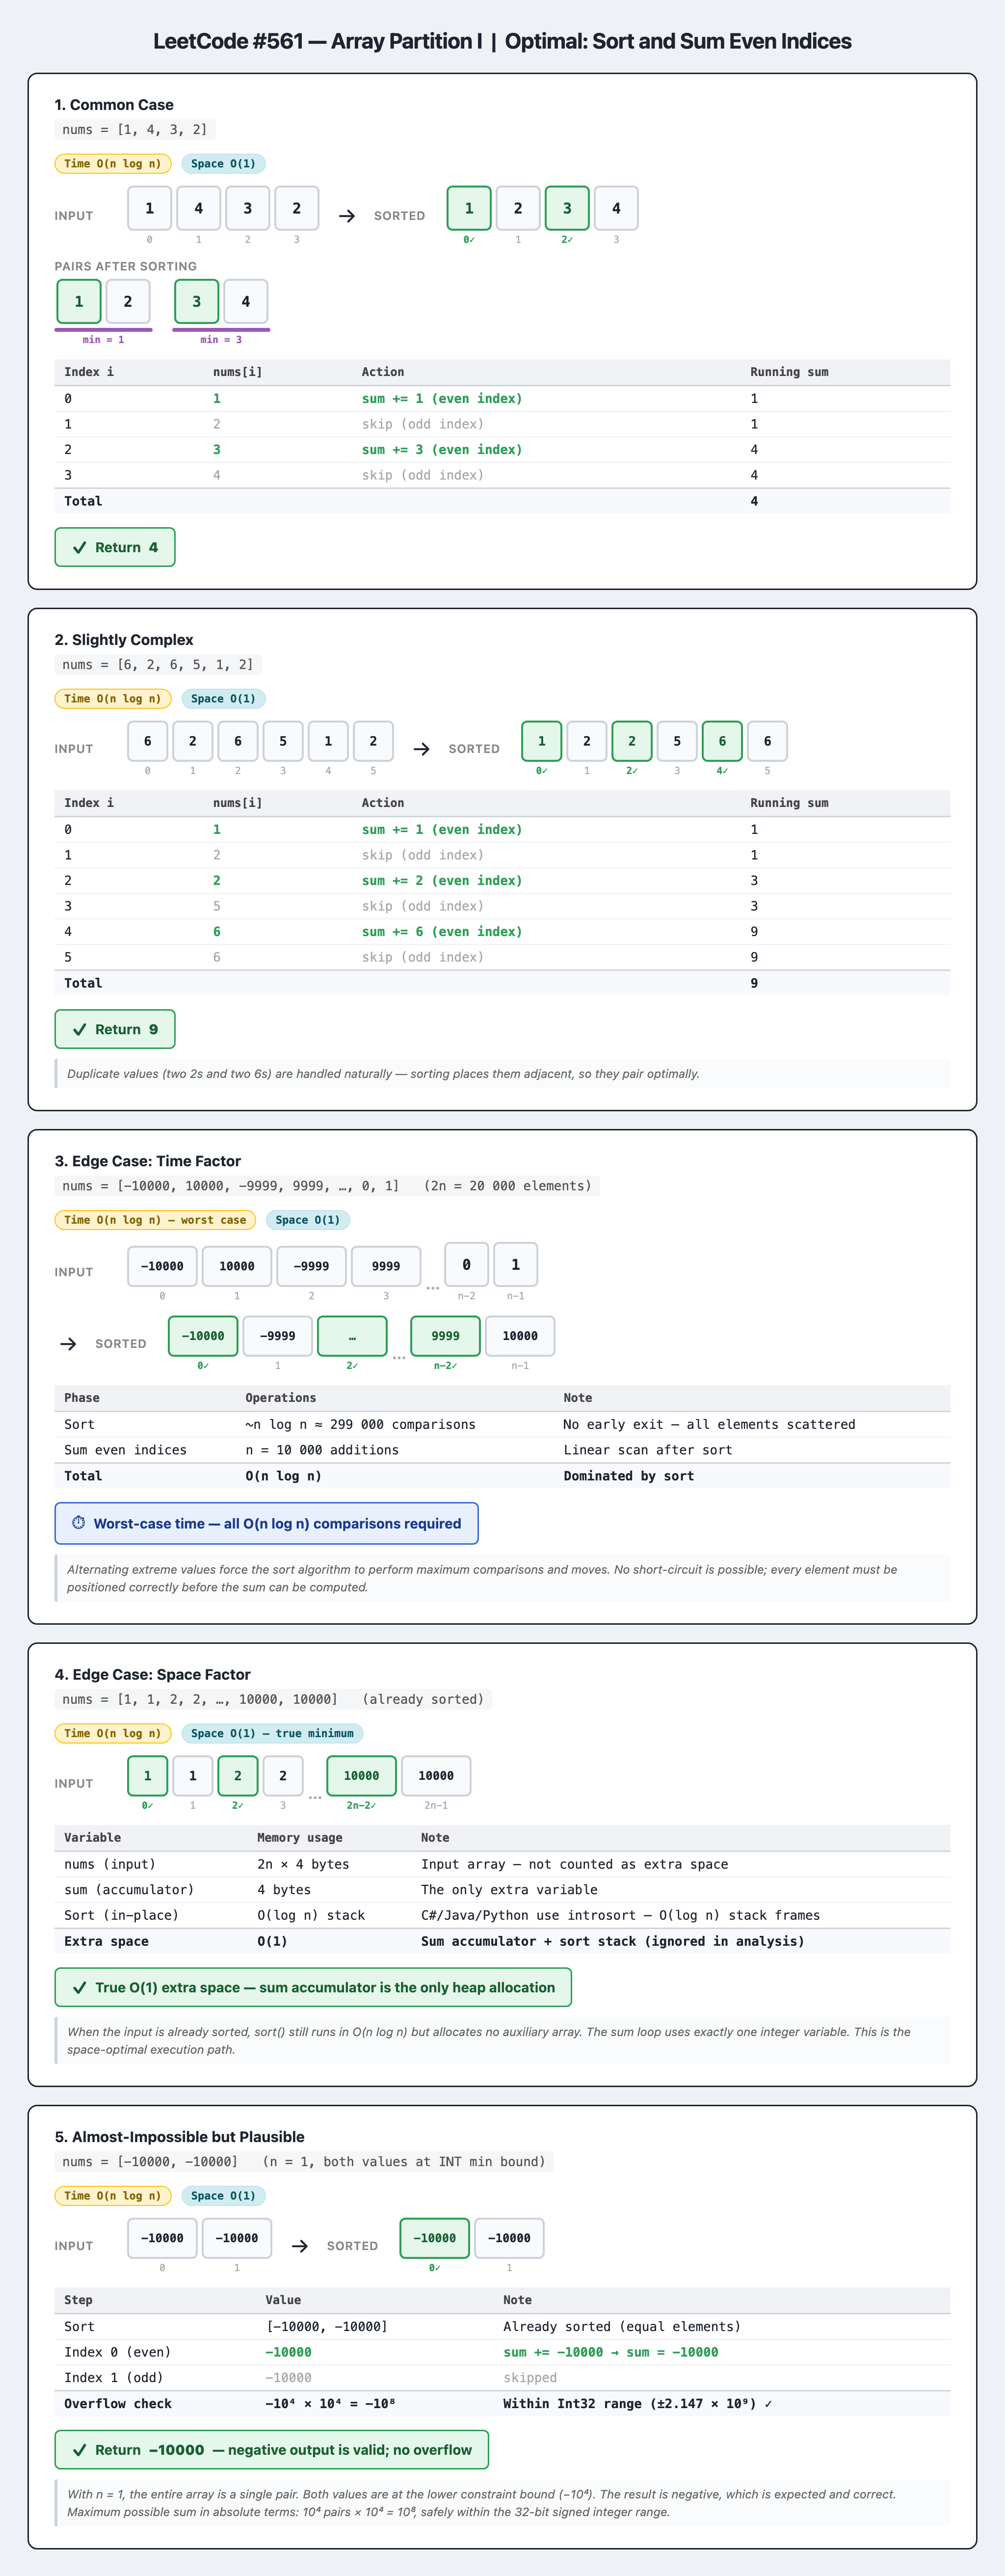